In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded")

All libraries loaded


In [4]:
df = pd.read_csv('loan_data.csv')

print("Shape:", df.shape)
print("\nAll Column Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9578, 14)

All Column Names:
['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']

First 5 rows:


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
# Rename columns to be cleaner
df.columns = ['credit_policy', 'purpose', 'int_rate', 'installment', 
              'log_annual_inc', 'dti', 'fico', 'days_with_cr_line', 
              'revol_bal', 'revol_util', 'inq_last_6mths', 
              'delinq_2yrs', 'pub_rec', 'not_fully_paid']

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Add a readable loan status column
df['loan_status'] = df['not_fully_paid'].map({0: 'Fully Paid', 1: 'Defaulted'})

# Add FICO risk band column
df['fico_band'] = pd.cut(df['fico'], 
                          bins=[0, 650, 700, 750, 850], 
                          labels=['High Risk', 'Medium Risk', 'Low Risk', 'Excellent'])

print("\nLoan Status Distribution:")
print(df['loan_status'].value_counts())

print("\nFICO Band Distribution:")
print(df['fico_band'].value_counts())

print("\nCleaning complete")

Missing values:
 credit_policy        0
purpose              0
int_rate             0
installment          0
log_annual_inc       0
dti                  0
fico                 0
days_with_cr_line    0
revol_bal            0
revol_util           0
inq_last_6mths       0
delinq_2yrs          0
pub_rec              0
not_fully_paid       0
dtype: int64

Loan Status Distribution:
loan_status
Fully Paid    8045
Defaulted     1533
Name: count, dtype: int64

FICO Band Distribution:
fico_band
Medium Risk    3990
Low Risk       3687
Excellent      1670
High Risk       231
Name: count, dtype: int64

Cleaning complete


In [6]:
# Local SQL database in memory
conn = sqlite3.connect(':memory:')
df.to_sql('loans', conn, index=False, if_exists='replace')

print("Data loaded into SQL database ✓")
print("Total records:", pd.read_sql("SELECT COUNT(*) as total FROM loans", conn).values[0][0])

Data loaded into SQL database ✓
Total records: 9578


In [7]:
query1 = """
SELECT 
    purpose,
    COUNT(*) as total_loans,
    SUM(not_fully_paid) as defaults,
    ROUND(AVG(not_fully_paid) * 100, 2) as default_rate_pct,
    ROUND(AVG(int_rate) * 100, 2) as avg_interest_rate
FROM loans
GROUP BY purpose
ORDER BY default_rate_pct DESC
"""

default_by_purpose = pd.read_sql(query1, conn)
print("=== DEFAULT RATE BY LOAN PURPOSE ===")
print(default_by_purpose)

=== DEFAULT RATE BY LOAN PURPOSE ===
              purpose  total_loans  defaults  default_rate_pct  \
0      small_business          619       172             27.79   
1         educational          343        69             20.12   
2    home_improvement          629       107             17.01   
3           all_other         2331       387             16.60   
4  debt_consolidation         3957       603             15.24   
5         credit_card         1262       146             11.57   
6      major_purchase          437        49             11.21   

   avg_interest_rate  
0              13.81  
1              11.99  
2              11.75  
3              11.68  
4              12.66  
5              11.97  
6              11.42  


In [8]:
query2 = """
SELECT 
    fico_band,
    COUNT(*) as total_loans,
    ROUND(AVG(int_rate) * 100, 2) as avg_interest_rate,
    ROUND(AVG(dti), 2) as avg_debt_to_income,
    SUM(not_fully_paid) as total_defaults,
    ROUND(AVG(not_fully_paid) * 100, 2) as default_rate_pct
FROM loans
GROUP BY fico_band
ORDER BY default_rate_pct DESC
"""

portfolio_health = pd.read_sql(query2, conn)
print("=== PORTFOLIO HEALTH BY FICO BAND ===")
print(portfolio_health)

=== PORTFOLIO HEALTH BY FICO BAND ===
     fico_band  total_loans  avg_interest_rate  avg_debt_to_income  \
0    High Risk          231              15.32               13.30   
1  Medium Risk         3990              14.04               13.82   
2     Low Risk         3687              11.46               12.79   
3    Excellent         1670               9.37                9.21   

   total_defaults  default_rate_pct  
0              74             32.03  
1             800             20.05  
2             535             14.51  
3             124              7.43  


In [9]:
query3 = """
SELECT
    COUNT(*) as total_loans,
    ROUND(AVG(int_rate) * 100, 2) as avg_interest_rate,
    ROUND(AVG(dti), 2) as avg_debt_to_income,
    ROUND(AVG(fico), 0) as avg_fico_score,
    SUM(not_fully_paid) as total_defaults,
    ROUND(AVG(not_fully_paid) * 100, 2) as overall_default_rate_pct,
    ROUND(AVG(installment), 2) as avg_monthly_installment
FROM loans
"""

kpi_summary = pd.read_sql(query3, conn)
print("=== OVERALL PORTFOLIO KPI SUMMARY ===")
print(kpi_summary.T)

=== OVERALL PORTFOLIO KPI SUMMARY ===
                                0
total_loans               9578.00
avg_interest_rate           12.26
avg_debt_to_income          12.61
avg_fico_score             711.00
total_defaults            1533.00
overall_default_rate_pct    16.01
avg_monthly_installment    319.09


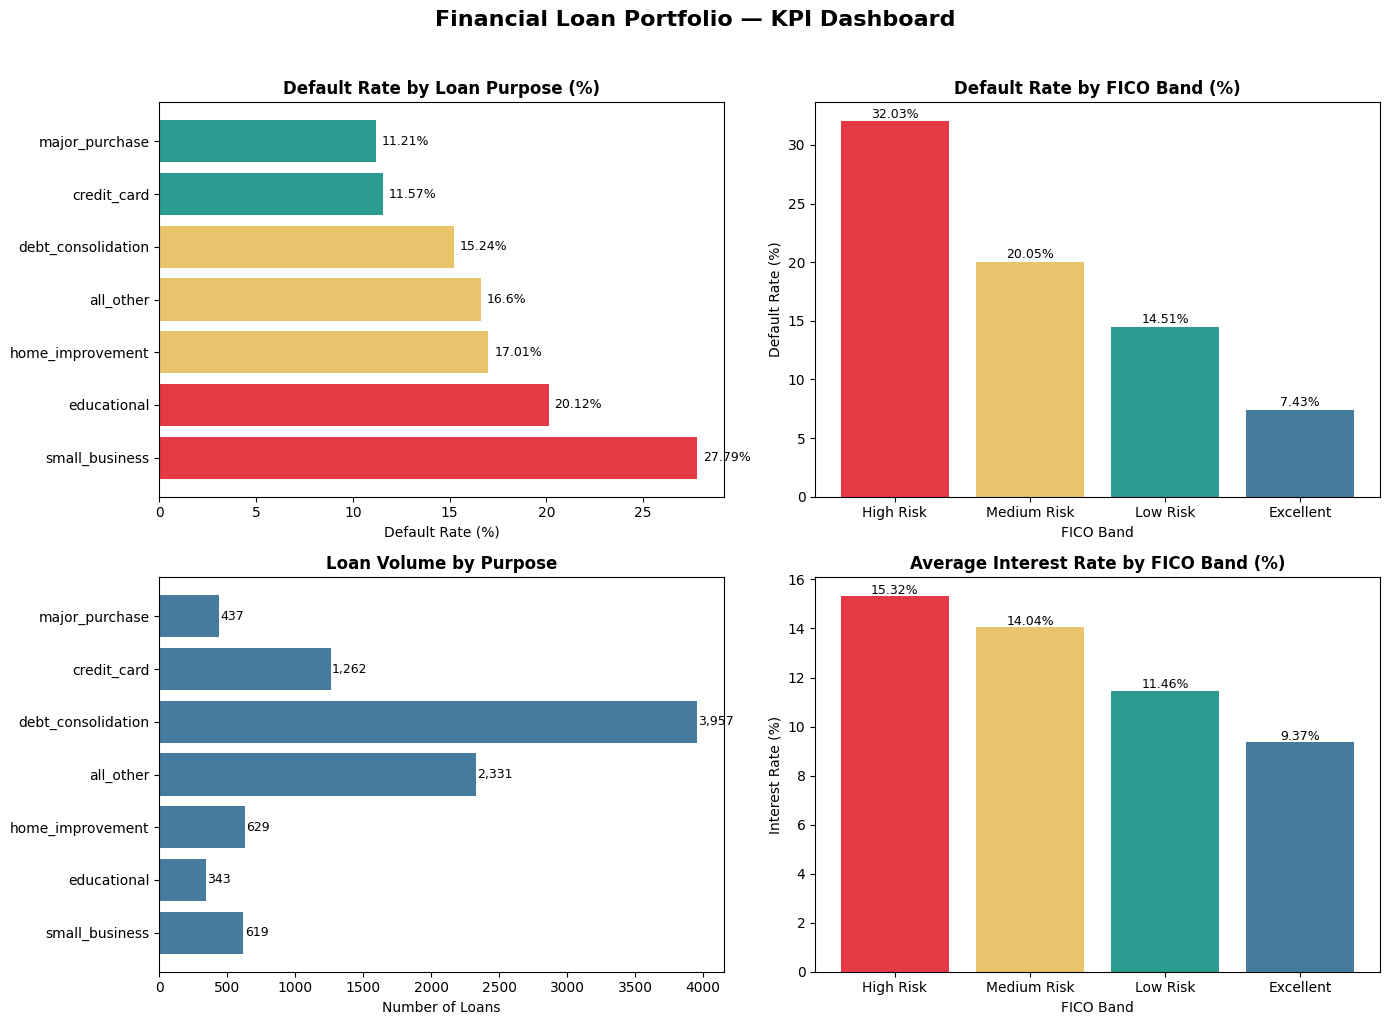

Charts saved


In [10]:
#Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Financial Loan Portfolio — KPI Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Default Rate by Purpose
colors1 = ['#E63946' if x > 20 else '#E9C46A' if x > 15 else '#2A9D8F' 
           for x in default_by_purpose['default_rate_pct']]
axes[0,0].barh(default_by_purpose['purpose'], 
               default_by_purpose['default_rate_pct'],
               color=colors1)
axes[0,0].set_title('Default Rate by Loan Purpose (%)', fontweight='bold')
axes[0,0].set_xlabel('Default Rate (%)')
for i, v in enumerate(default_by_purpose['default_rate_pct']):
    axes[0,0].text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

# Chart 2 — Portfolio Health by FICO Band
colors2 = ['#E63946', '#E9C46A', '#2A9D8F', '#457B9D']
axes[0,1].bar(portfolio_health['fico_band'], 
              portfolio_health['default_rate_pct'],
              color=colors2)
axes[0,1].set_title('Default Rate by FICO Band (%)', fontweight='bold')
axes[0,1].set_xlabel('FICO Band')
axes[0,1].set_ylabel('Default Rate (%)')
for i, v in enumerate(portfolio_health['default_rate_pct']):
    axes[0,1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)

# Chart 3 — Loan Volume by Purpose
axes[1,0].barh(default_by_purpose['purpose'],
               default_by_purpose['total_loans'],
               color='#457B9D')
axes[1,0].set_title('Loan Volume by Purpose', fontweight='bold')
axes[1,0].set_xlabel('Number of Loans')
for i, v in enumerate(default_by_purpose['total_loans']):
    axes[1,0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# Chart 4 — Interest Rate vs FICO Band
axes[1,1].bar(portfolio_health['fico_band'],
              portfolio_health['avg_interest_rate'],
              color=['#E63946', '#E9C46A', '#2A9D8F', '#457B9D'])
axes[1,1].set_title('Average Interest Rate by FICO Band (%)', fontweight='bold')
axes[1,1].set_xlabel('FICO Band')
axes[1,1].set_ylabel('Interest Rate (%)')
for i, v in enumerate(portfolio_health['avg_interest_rate']):
    axes[1,1].text(i, v + 0.1, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('kpi_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved")

In [11]:
# Export all tables for Power BI
df.to_csv('loans_clean.csv', index=False)
default_by_purpose.to_csv('default_by_purpose.csv', index=False)
portfolio_health.to_csv('portfolio_health.csv', index=False)
kpi_summary.to_csv('kpi_summary.csv', index=False)

print("All files exported for Power BI")
print("\nFiles created:")
print("   loans_clean.csv")
print("   default_by_purpose.csv")
print("   portfolio_health.csv")
print("   kpi_summary.csv")

All files exported for Power BI

Files created:
   loans_clean.csv
   default_by_purpose.csv
   portfolio_health.csv
   kpi_summary.csv
